# Rotatable bonds vs. conformer-ensemble variance

This notebook computes, for each molecule in an ensemble JSONL file, the variance of its conformer ensemble (based on relative MMFF energies carried in the ensemble) and correlates it with the molecule's rotatable-bond count. A scatter plot visualizes the relationship.

Notes:
- The ensemble JSONL is produced by `run_batch.py ... --tier tier1` (or `--tier xtb`).
- Each molecule entry contains conformers with relative energies `energy_kcal_mol` and Boltzmann weights `weight`. We compute the Boltzmann-weighted variance of the relative energies as a simple measure of ensemble spread.
- If a molecule has a single conformer, variance is 0.


In [1]:
# Configuration — change the path if needed
ensemble_path = '/home/alex/freesolv_gpr/data/structures/ensembles_tier1.jsonl'  # or 'ensembles_xtb.jsonl' if available
# Plot kind: 'scatter' (default) or 'box' for grouped boxplots by rotatable-bond count
plot_kind = 'box'  # options: 'scatter', 'box'


In [2]:
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# Load ensembles (JSON Lines)
records = []
path = Path(ensemble_path)
assert path.exists(), f'Ensemble file not found: {path}'
with path.open() as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rec = json.loads(line)
            records.append(rec)
        except json.JSONDecodeError:
            # Some files may contain a single big JSON array; attempt to parse once
            f.seek(0)
            data = json.load(f)
            if isinstance(data, list):
                records = data
            else:
                raise
            break
len(records)


642

In [4]:
def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    if x.size == 0:
        return np.nan
    if w.size != x.size:
        raise ValueError('weights and values must be same length')
    s = w.sum()
    if s == 0:
        return float(np.nan)
    return float((w * x).sum() / s)


def weighted_var(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    if x.size <= 1:
        return 0.0
    m = weighted_mean(x, w)
    s = w.sum()
    if s == 0:
        return float(np.nan)
    # population-style weighted variance
    return float((w * (x - m) ** 2).sum() / s)


In [5]:
rows = []
for rec in records:
    nrot = rec.get('n_rotatable_bonds')
    smiles = rec.get('smiles')
    confs = rec.get('conformers', [])
    energies = [c.get('energy_kcal_mol', np.nan) for c in confs]
    weights = [c.get('weight', np.nan) for c in confs]
    # Filter out conformers missing energy or weight
    #good = [i for i, (e, w) in enumerate(zip(energies, weights)) if np.isfinite(e) and np.isfinite(w)]
    #energies = [energies[i] for i in good]
    #weights = [weights[i] for i in good]
    wvar = weighted_var(energies, weights)
    rows.append({
        'smiles': smiles,
        'n_rotatable_bonds': nrot,
        'n_final': rec.get('n_final', len(confs)),
        'energy_var_kcal2': wvar,
        'energy_std_kcal': math.sqrt(wvar) if np.isfinite(wvar) else np.nan,

    })

df = pd.DataFrame(rows)
df.head()


,smiles,n_rotatable_bonds,n_final,energy_var_kcal2,energy_std_kcal
0,CS(=O)(=O)Cl,0,1,0.000000e+00,0.000000e+00
1,CCc1cnccn1,1,2,1.364010e-18,1.167908e-09
2,CC(C)C=C,1,1,0.000000e+00,0.000000e+00
3,C(Br)Br,0,1,0.000000e+00,0.000000e+00
4,CN(C)C(=O)c1ccc(cc1)OC,2,4,2.132847e-02,1.460427e-01


In [6]:
# Drop rows with missing values and compute correlation
clean = df.dropna(subset=['n_rotatable_bonds', 'energy_std_kcal'])
x = clean['n_rotatable_bonds'].to_numpy(dtype=float)
y = clean['energy_std_kcal'].to_numpy(dtype=float)
if x.size > 1 and np.std(x) > 0 and np.std(y) > 0:
    r = np.corrcoef(x, y)[0, 1]
else:
    r = np.nan
print(f'Pearson r (rotatable bonds vs energy std): {r:.3f}')
len(clean)


Pearson r (rotatable bonds vs energy std): 0.816


642

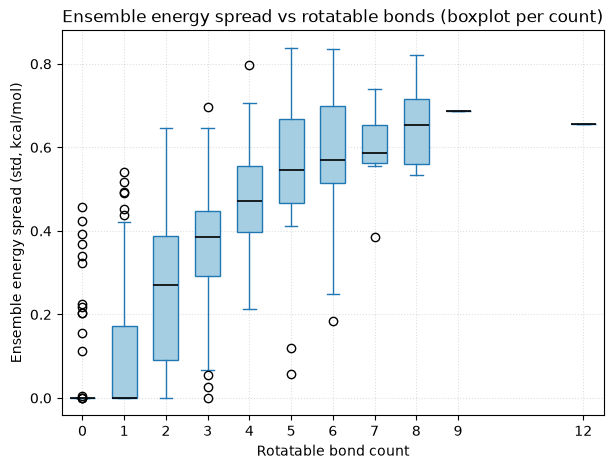

In [7]:
# Plot: scatter (default) or boxplot by rotatable-bond count
plt.figure(figsize=(7, 5))
if plot_kind == 'box':
    # Group energy std values by rotatable-bond count
    counts = sorted(pd.unique(clean['n_rotatable_bonds']))
    data_by_count = [clean.loc[clean['n_rotatable_bonds'] == c, 'energy_std_kcal'].to_numpy(dtype=float) for c in counts]
    bp = plt.boxplot(
        data_by_count,
        positions=counts,
        widths=0.6,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color='black', linewidth=1.2),
        boxprops=dict(facecolor='#a6cee3', edgecolor='#1f78b4'),
        whiskerprops=dict(color='#1f78b4'),
        capprops=dict(color='#1f78b4')
    )
    plt.xticks(counts)
    plt.title('Ensemble energy spread vs rotatable bonds (boxplot per count)')
else:
    # Scatter plot with slight jitter on x for visibility
    rng = np.random.default_rng(0)
    x_jitter = x + rng.normal(0, 0.06, size=x.shape)
    plt.scatter(x_jitter, y, alpha=0.6, edgecolor='k', linewidths=0.3)
    if x.size:
        plt.xticks(sorted(pd.unique(clean['n_rotatable_bonds'])))
    plt.title('Rotatable bonds vs. conformer-ensemble variance (energy-based)')

plt.xlabel('Rotatable bond count')
plt.ylabel('Ensemble energy spread (std, kcal/mol)')
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()
